<a href="https://colab.research.google.com/github/priyansh-commits/practice/blob/main/customer_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
abdullah0a_telecom_customer_churn_insights_for_analysis_path = kagglehub.dataset_download('abdullah0a/telecom-customer-churn-insights-for-analysis')

print('Data source import complete.')

100%|██████████| 14.7k/14.7k [00:00<00:00, 21.5MB/s]

Extracting files...
Data source import complete.


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
import os
import kagglehub
import pandas as pd
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

path = kagglehub.dataset_download(
    "abdullah0a/telecom-customer-churn-insights-for-analysis"
)

print(path)

print(os.listdir(path))    # See the files inside

df = pd.read_csv(os.path.join(path, "customer_churn_data.csv"))
df.head()

Using Colab cache for faster access to the 'telecom-customer-churn-insights-for-analysis' dataset.
/kaggle/input/telecom-customer-churn-insights-for-analysis
['customer_churn_data.csv', '.nfs000000005b4cceda0000003c']


,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
MonthlyCharges,0
ContractType,0
InternetService,297
TotalCharges,0
TechSupport,0
Churn,0


In [ ]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['InternetService'].fillna('Nan', inplace=True)
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
MonthlyCharges,0
ContractType,0
InternetService,0
TotalCharges,0
TechSupport,0
Churn,0


In [ ]:
df['Churn']=df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)
df['TechSupport']=df['TechSupport'].apply(lambda x: 1 if x == 'Yes' else 0)
df['Churn'].value_counts()

,count
Churn,
1,883
0,117


In [ ]:
df['TechSupport'].value_counts()
df['Gender'].value_counts()

,count
Gender,
Female,538
Male,462


In [ ]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,1,1
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,1,1
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,0,1
3,4,60,Female,8,102.34,One-Year,DSL,818.72,1,1
4,5,42,Male,32,69.01,Month-to-Month,Nan,2208.32,0,1


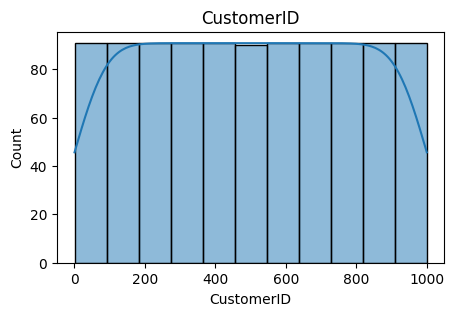

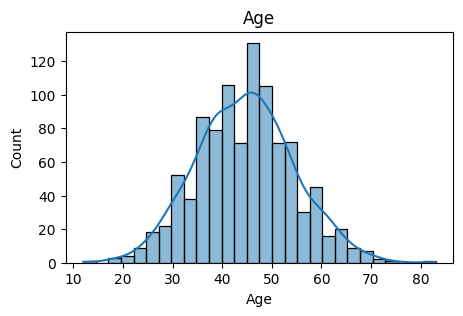

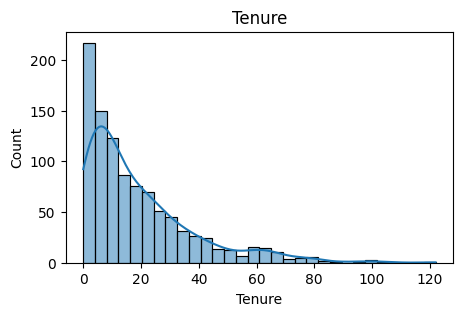

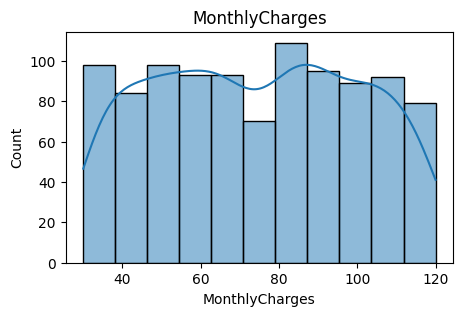

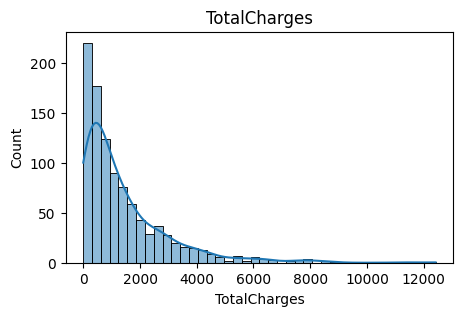

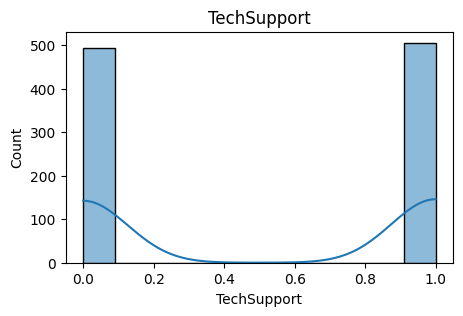

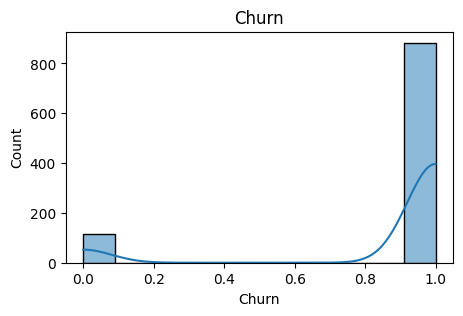

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

<Axes: xlabel='Churn', ylabel='count'>

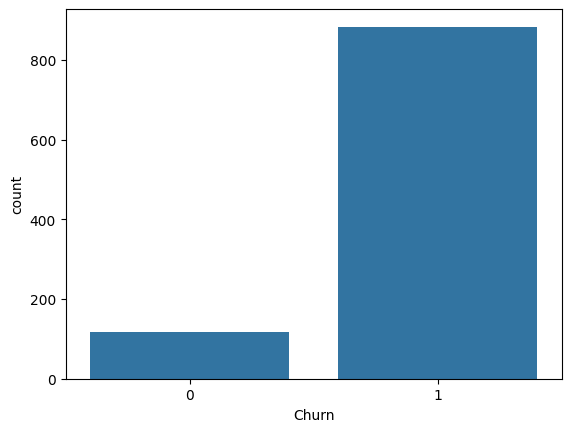

In [ ]:
df['Churn'].value_counts()
sns.countplot(x='Churn', data=df)

<Axes: >

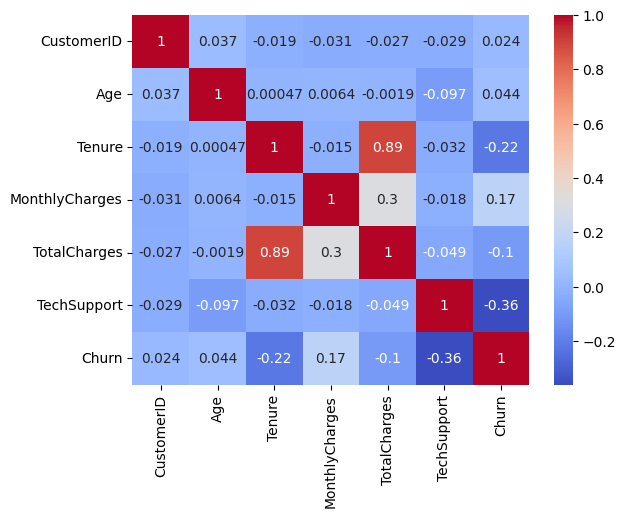

In [ ]:
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')

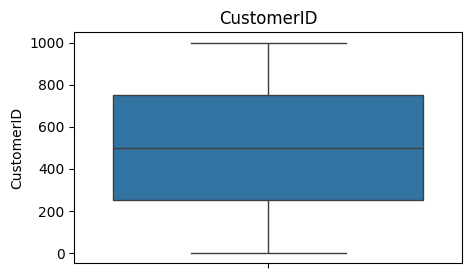

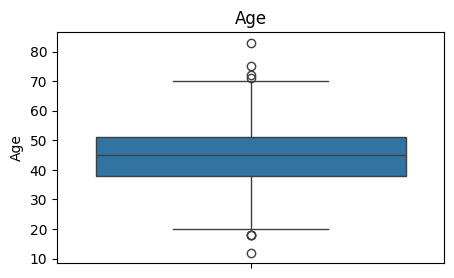

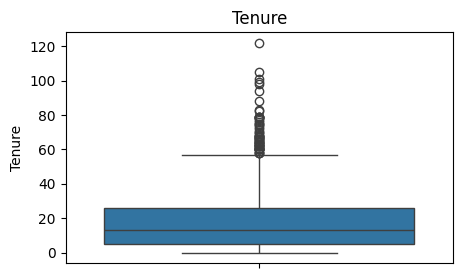

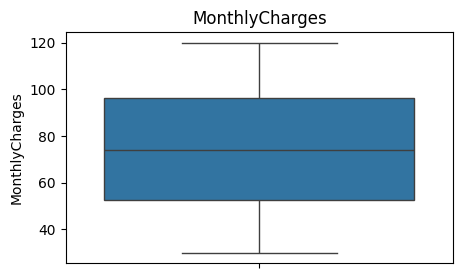

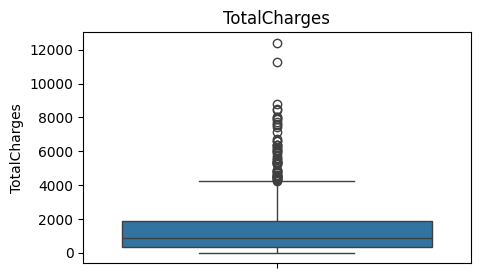

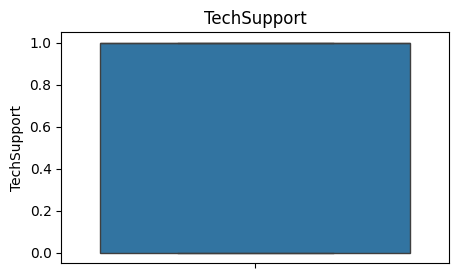

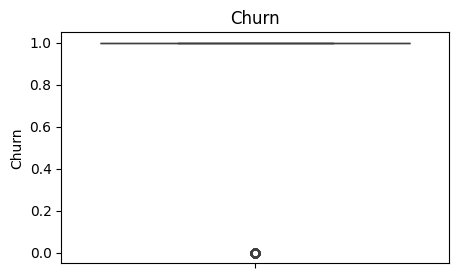

In [ ]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(df[col])
    plt.title(col)
    plt.show()
# age,tenure,total chrgge have many outliers

<Axes: xlabel='Churn', ylabel='Age'>

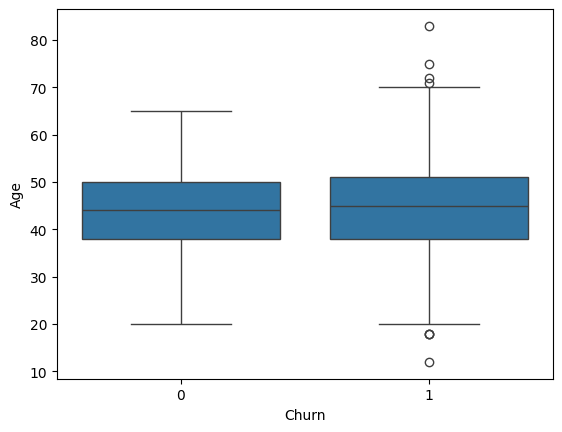

In [ ]:
sns.boxplot(x='Churn', y='Age', data=df)

<Axes: xlabel='Age', ylabel='Density'>

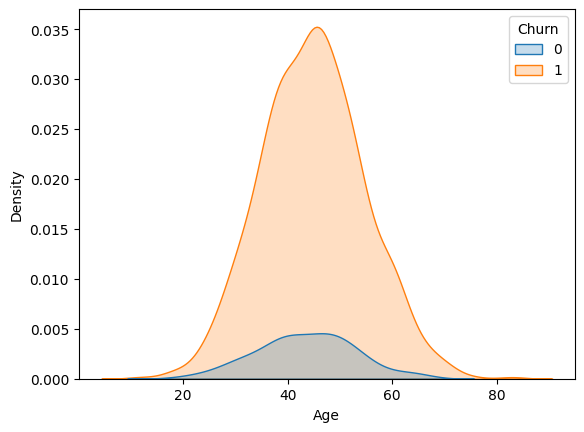

In [ ]:
sns.kdeplot(data=df, x='Age', hue='Churn', fill=True)

In [ ]:
df.groupby('Churn')['Age'].mean()

,Age
Churn,
0,43.487179
1,44.831257


In [ ]:
df.drop('CustomerID',axis=1,inplace=True)

In [ ]:
# One-hot encode all object columns
df = pd.get_dummies(df, columns=df.select_dtypes(include='object').columns, drop_first=True)
df = pd.get_dummies(df, drop_first = True, dtype = int)
df.head()
X = df.drop(columns = ['Churn'], axis = 1)
y = df['Churn']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    random_state = 42)

In [ ]:
df.head()

,Age,Tenure,MonthlyCharges,TotalCharges,TechSupport,Churn,Gender_Male,ContractType_One-Year,ContractType_Two-Year,InternetService_Fiber Optic,InternetService_Nan
0,49,4,88.35,353.40,1,1,True,False,False,True,False
1,43,0,36.67,0.00,1,1,True,False,False,True,False
2,51,2,63.79,127.58,0,1,False,False,False,True,False
3,60,8,102.34,818.72,1,1,False,True,False,False,False
4,42,32,69.01,2208.32,0,1,True,False,False,False,True


In [ ]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
1,88.3
0,11.7


**LOGISTIC** **REGRESSION**

In [ ]:

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


clf1 = LogisticRegression(max_iter=10000, random_state=0)
clf1.fit(X_train, y_train)

acc = accuracy_score(y_test, clf1.predict(X_test)) * 100
print(f"Logistic Regression model accuracy: {acc:.2f}%")
classification_report(y_test, clf1.predict(X_test))

Logistic Regression model accuracy: 93.50%


'              precision    recall  f1-score   support\n\n           0       0.86      0.52      0.65        23\n           1       0.94      0.99      0.96       177\n\n    accuracy                           0.94       200\n   macro avg       0.90      0.76      0.81       200\nweighted avg       0.93      0.94      0.93       200\n'

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
clf2 = LogisticRegression(max_iter=10000, random_state=0)
clf2.fit(X_train_scaled, y_train)

acc = accuracy_score(y_test, clf2.predict(X_test_scaled)) * 100
print(f"Logistic Regression model accuracy: {acc:.2f}%")
classification_report(y_test, clf2.predict(X_test_scaled))

Logistic Regression model accuracy: 95.50%


'              precision    recall  f1-score   support\n\n           0       0.85      0.74      0.79        23\n           1       0.97      0.98      0.97       177\n\n    accuracy                           0.95       200\n   macro avg       0.91      0.86      0.88       200\nweighted avg       0.95      0.95      0.95       200\n'

In [ ]:
clf3 = LogisticRegression(max_iter=10000, random_state=0,class_weight='balanced')
clf3.fit(X_train_scaled, y_train)

acc = accuracy_score(y_test, clf3.predict(X_test_scaled)) * 100
print(f"Logistic Regression model accuracy: {acc:.2f}%")
classification_report(y_test, clf3.predict(X_test_scaled))

Logistic Regression model accuracy: 90.50%


'              precision    recall  f1-score   support\n\n           0       0.55      1.00      0.71        23\n           1       1.00      0.89      0.94       177\n\n    accuracy                           0.91       200\n   macro avg       0.77      0.95      0.83       200\nweighted avg       0.95      0.91      0.92       200\n'

0.9845246868091377


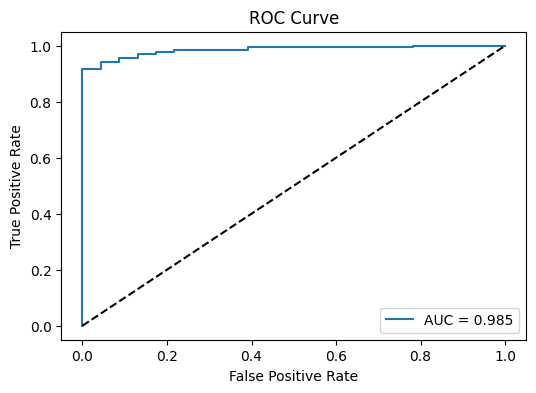

In [ ]:
from sklearn.metrics import roc_auc_score

y_prob = clf2.predict_proba(X_test_scaled)[:,1]
auc = roc_auc_score(y_test, y_prob)
print(auc)
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

BEST ACC SCORE IS OF clf2-95.5
and ROC-AUC SOCRE-98.5

In [ ]:
df.sample(5)

,Age,Tenure,MonthlyCharges,TotalCharges,TechSupport,Churn,Gender_Male,ContractType_One-Year,ContractType_Two-Year,InternetService_Fiber Optic,InternetService_Nan
233,38,122,69.58,8488.76,0,1,False,False,False,False,False
723,52,30,50.70,1521.00,0,1,False,False,True,False,False
512,42,12,34.53,414.36,1,1,True,False,False,True,False
314,58,36,81.41,2930.76,0,1,False,False,False,False,False
674,30,9,117.64,1058.76,0,1,True,False,False,False,True


**DECISION TREE CLASSIFIER**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
accuracy_score(y_test, dt_pred)

0.995

In [ ]:
classification_report(y_test, dt_pred)
from sklearn.metrics import roc_auc_score

dt_prob = dt.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, dt_prob))

ROC-AUC: 0.9971751412429379


**RANDOM FOREST**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
accuracy_score(y_test, rf_pred)
classification_report(y_test, rf_pred)
rf.score(X_test, y_test)
rf_prob = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, rf_prob)
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        23
           1       1.00      0.99      1.00       177

    accuracy                           0.99       200
   macro avg       0.98      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



**The Random Forest Classifier achieved the best performance among all evaluated models. It obtained 99% accuracy, precision, recall, and F1-score on the test set, along with a ROC-AUC score of 1.0, indicating perfect discrimination between churning and non-churning customers. Feature importance analysis identified Tenure, Contract Type, Tech Support, Monthly Charges, and Total Charges as the most influential factors affecting customer churn.**

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf, X, y,
    cv=5,
    scoring='roc_auc'
)

print(scores)
print("Mean AUC:", scores.mean())

[1. 1. 1. 1. 1.]
Mean AUC: 1.0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=42
)

scores = cross_val_score(
    rf,
    X,
    y,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

print(scores)
print("Mean:", scores.mean())
print("Std:", scores.std())

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        23
           1       0.99      1.00      1.00       177

    accuracy                           0.99       200
   macro avg       1.00      0.98      0.99       200
weighted avg       1.00      0.99      0.99       200

ROC-AUC: 1.0
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1.]
Mean: 1.0
Std: 0.0


In [ ]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

importance_df

,Feature,Importance
1,Tenure,0.179111
6,ContractType_One-Year,0.172005
4,TechSupport,0.164584
2,MonthlyCharges,0.145878
7,ContractType_Two-Year,0.134244
3,TotalCharges,0.112040
9,InternetService_Nan,0.035636
0,Age,0.034422
8,InternetService_Fiber Optic,0.013388
5,Gender_Male,0.008692


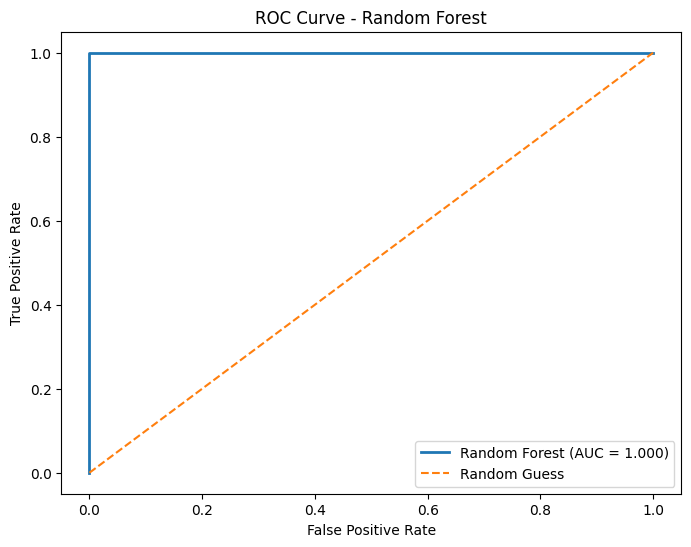

ROC-AUC Score: 1.0


In [ ]:
from sklearn.metrics import roc_curve
rf_prob = rf.predict_proba(X_test)[:,1]

rf_auc = roc_auc_score(y_test, rf_prob)

# ROC Curve points
fpr, tpr, thresholds = roc_curve(y_test, rf_prob)

# Plot ROC Curve
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'Random Forest (AUC = {rf_auc:.3f})'
)

# Random classifier line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    label='Random Guess'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')

plt.show()

print("ROC-AUC Score:", rf_auc)

In [ ]:
results = {
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        0.955,
        0.995,
        0.990
    ],
    'Precision': [
        0.95,
        0.99,
        0.995
    ],
    'Recall': [
        0.95,
        0.99,
        0.98
    ],
    'F1': [
        0.95,
        0.99,
        0.99
    ],
    'ROC-AUC': [
        0.985,
        0.997,
        1.000
    ]
}

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.955,0.950,0.95,0.95,0.985
1,Decision Tree,0.995,0.990,0.99,0.99,0.997
2,Random Forest,0.990,0.995,0.98,0.99,1.000


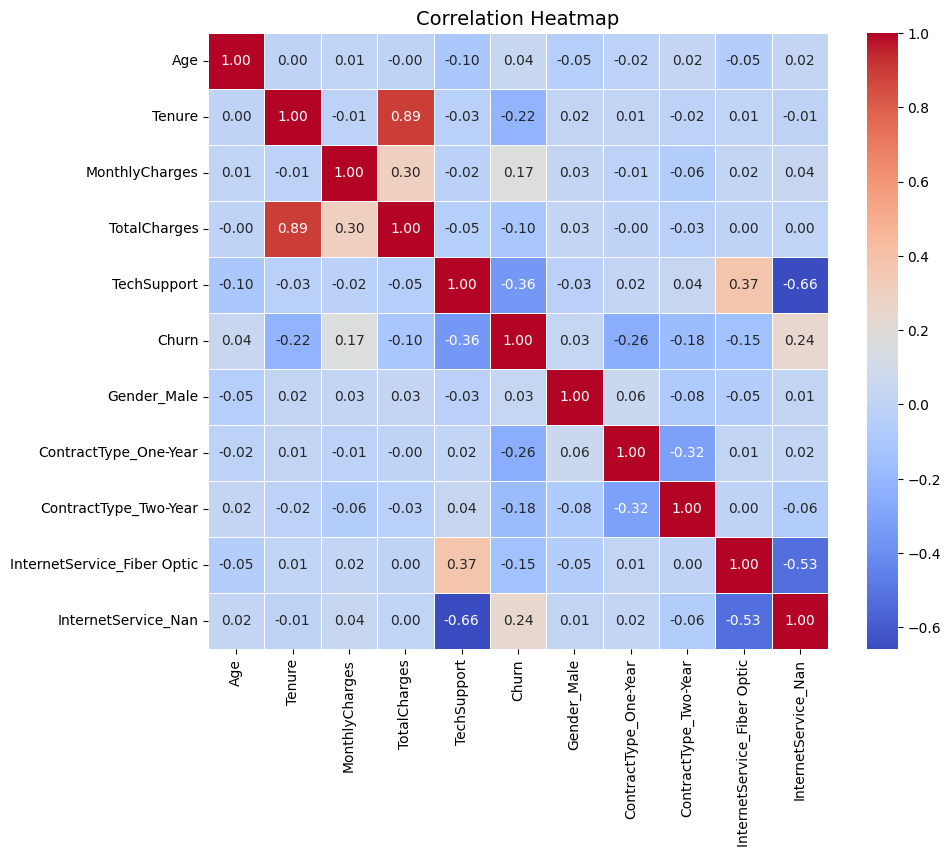

In [ ]:
# Correlation matrix
corr = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=14)
plt.show()

**SUMMARY**


*   Customers with longer tenure are significantly less likely to churn.
*   Customers with one-year and two-year contracts exhibit lower churn rates than month-to-month customers.
* Technical support plays a crucial role in customer retention.
* Higher monthly charges are associated with an increased likelihood of churn.
* Gender and age have relatively little impact on customer churn behavior.




In [ ]:
import joblib

# Save trained Random Forest
joblib.dump(rf, 'churn_model.pkl')

# Save the exact feature names and order used during training
joblib.dump(X.columns.tolist(), 'features.pkl')

print("Model and features saved successfully!")

Model and features saved successfully!
